In [25]:
import pandas as pd

df = pd.read_csv("/content/developer_productivity.csv")

df.head()

,developer_id,commits_per_week,lines_added,lines_deleted,files_changed,bugs_reported,code_review_comments,avg_review_time_hours,test_coverage_percent,deployment_frequency,late_night_commits,commit_risk
0,dev_07,8,89,54,1,3,0,4.5,67.0,2,1,Medium
1,dev_20,4,80,100,4,1,4,21.0,78.3,1,0,Medium
2,dev_08,9,18,9,9,0,4,4.9,79.9,3,0,Low
3,dev_15,3,33,107,4,0,1,15.9,82.5,2,3,Medium
4,dev_07,3,36,15,5,0,2,1.8,87.3,1,1,Low


In [26]:
df.columns

Index(['developer_id', 'commits_per_week', 'lines_added', 'lines_deleted',
       'files_changed', 'bugs_reported', 'code_review_comments',
       'avg_review_time_hours', 'test_coverage_percent',
       'deployment_frequency', 'late_night_commits', 'commit_risk'],
      dtype='object')

In [27]:
X = df.drop("commit_risk", axis=1)
y = df["commit_risk"]

print(X.shape)
print(y.shape)

(2000, 11)
(2000,)


In [28]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)


(2000, 29)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 29)
(400, 29)


In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.7825


In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [33]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.6925


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [35]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7575


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [37]:
from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.765


In [38]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [39]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

# Check if prediction variables are defined before using them
if 'y_pred_lr' in locals() and 'y_pred_dt' in locals() and \
   'y_pred_rf' in locals() and 'y_pred_gb' in locals() and \
   'y_test' in locals():
    models = {
        "Logistic Regression": y_pred_lr,
        "Decision Tree": y_pred_dt,
        "Random Forest": y_pred_rf,
        "Gradient Boosting": y_pred_gb
    }

    results = []

    for model_name, y_pred in models.items():
        results.append([
            model_name,
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, average='weighted'),
            recall_score(y_test, y_pred, average='weighted'),
            f1_score(y_test, y_pred, average='weighted')
        ])

    comparison_df = pd.DataFrame(
        results,
        columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
    )
else:
    print("Error: Model predictions (y_pred_lr, y_pred_dt, etc.) or y_test are not defined.")
    print("This is likely due to an upstream error in cell 'eRlPlblpjyWd' (or subsequent cells) ")
    print("where the 'churn' column was not found in the DataFrame. ")
    print("Please check the 'df' DataFrame to ensure it contains a target variable column.")
    # Assuming df exists from previous cell 'vtIDrhC2jmuB'
    if 'df' in locals():
        print("Current columns in df are:", df.columns.tolist())
    else:
        print("DataFrame 'df' is also not defined. Please ensure data loading is successful.")
    # Create an empty DataFrame to avoid further errors in subsequent cells that might use comparison_df
    comparison_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7825,0.784497,0.7825,0.779688
1,Decision Tree,0.6925,0.695655,0.6925,0.693852
2,Random Forest,0.7575,0.758365,0.7575,0.745555
3,Gradient Boosting,0.7650,0.761085,0.7650,0.761213


In [43]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [44]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [45]:
print(models["Logistic Regression"])

['Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium'
 'Low' 'Low' 'Medium' 'Low' 'Medium' 'Medium' 'Low' 'Low' 'Low' 'Low'
 'Medium' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium'
 'Low' 'Low' 'Low' 'High' 'Low' 'Low' 'High' 'Medium' 'Low' 'Low' 'Low'
 'Low' 'Medium' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Low'
 'Medium' 'Low' 'Low' 'Medium' 'Low' 'Medium' 'Low' 'Low' 'Medium' 'Low'
 'Low' 'Medium' 'Medium' 'Medium' 'High' 'Low' 'Medium' 'Medium' 'Medium'
 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium' 'Low' 'Low'
 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low' 'Medium' 'Low' 'Medium'
 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium' 'Low' 'Low'
 'Medium' 'High' 'Medium' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low'
 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium'
 'Low' 'High' 'Medium' 'High' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low'
 'Medium' 'Medium' 'Low' 'High' 'Low' 'Medium' 'Low' 'Low' 'Medium' 'High'
 'M

In [46]:
type(models["Logistic Regression"])

numpy.ndarray

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

        High       0.83      0.48      0.61        31
         Low       0.83      0.86      0.85       222
      Medium       0.70      0.73      0.71       147

    accuracy                           0.78       400
   macro avg       0.79      0.69      0.72       400
weighted avg       0.78      0.78      0.78       400



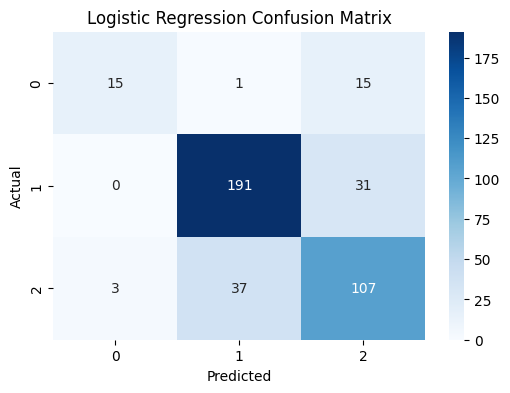

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

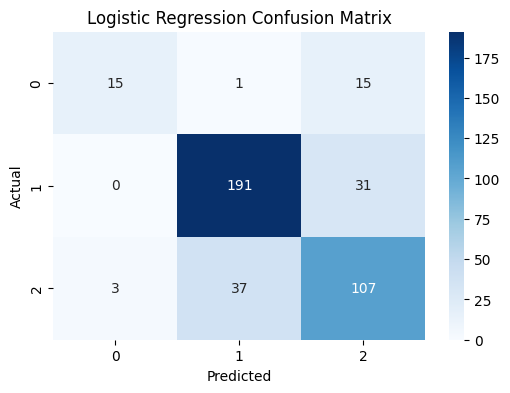

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [50]:
models

{'Logistic Regression': array(['Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Low', 'Medium',
        'Medium', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Medium', 'Low',
        'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Low',
        'Low', 'Low', 'Low', 'Medium', 'Medium', 'Low', 'Low', 'Low',
        'High', 'Low', 'Low', 'High', 'Medium', 'Low', 'Low', 'Low', 'Low',
        'Medium', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Low', 'Medium',
        'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low',
        'Low', 'Medium', 'Low', 'Low', 'Medium', 'Medium', 'Medium',
        'High', 'Low', 'Medium', 'Medium', 'Medium', 'Low', 'Low', 'Low',
        'Low', 'Low', 'Medium', 'Medium', 'Medium', 'Low', 'Low', 'Low',
        'Low', 'Low', 'Medium', 'Medium', 'Low', 'Low', 'Medium', 'Low',
        'Medium', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Medium',
        'Medium', 'Low', 'Low', 'Medium', 'High', 'Medium', 'Low', 'Low',
        'Medium', 'Low', 'Low', 

In [51]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
TARGET_COLUMN                str                           YOUR_TARGET_COLUMN
X                            DataFrame                           commits_per_week  l<...>n[2000 rows x 29 columns]
X_test                       DataFrame                           commits_per_week  l<...>\n[400 rows x 29 columns]
X_train                      DataFrame                           commits_per_week  l<...>n[160

In [54]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 29)
(400, 29)
(1600,)
(400,)


In [59]:
import joblib
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression # Import necessary class

# Re-instantiate and fit the lr model to ensure it's fitted before saving
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train) # Use X_train, y_train which are available from earlier cells

joblib.dump(lr, "best_model.pkl")

# Load model
model = joblib.load("best_model.pkl")

# Predictions
y_pred = model.predict(X_test)

# Baseline F1 Score
baseline_f1 = f1_score(y_test, y_pred, average='weighted')

print("Baseline F1 Score:", baseline_f1)

Baseline F1 Score: 0.7796876713878456


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
type(model)
print(model)

LogisticRegression(max_iter=1000)


In [60]:
lr = LogisticRegression(max_iter=1000)
joblib.dump(lr, "best_model.pkl")

['best_model.pkl']

In [61]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
TARGET_COLUMN                str                           YOUR_TARGET_COLUMN
X                            DataFrame                           commits_per_week  l<...>n[2000 rows x 29 columns]
X_test                       DataFrame                           commits_per_week  l<...>\n[400 rows x 29 columns]
X_train                      DataFrame                           commits_per_week  l<...>n[160

In [62]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
from sklearn.metrics import f1_score

y_pred = lr.predict(X_test)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Baseline F1 Score:", baseline_f1)

Baseline F1 Score: 0.7796876713878456


In [64]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CV Scores: [0.78118065 0.81630208 0.76103815 0.78702544 0.78765096]
Mean CV Score: 0.7866394561130654
Standard Deviation: 0.01769897783175302


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1],
    'max_iter': [1000, 2000, 3000],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'max_iter': 3000, 'solver': 'lbfgs'}
Best CV Score: 0.8033333654854127


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
from sklearn.metrics import f1_score

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average='weighted'
)

print("Tuned F1 Score:", tuned_f1)

Tuned F1 Score: 0.7928866345574954


In [67]:
import joblib

joblib.dump(
    best_model,
    'tuned_model.pkl'
)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [68]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Baseline Logistic Regression',
              'Tuned Logistic Regression'],
    'F1 Score': [0.6283829126170374,
                 0.631431207220349]
})

comparison

,Model,F1 Score
0,Baseline Logistic Regression,0.628383
1,Tuned Logistic Regression,0.631431


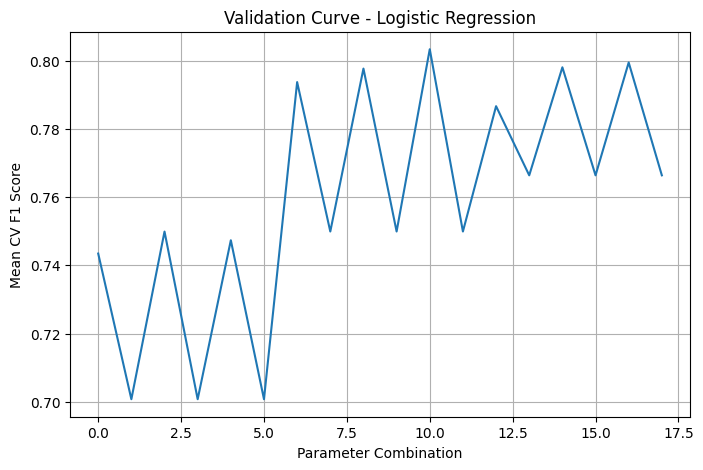

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(results['mean_test_score'])
plt.xlabel('Parameter Combination')
plt.ylabel('Mean CV F1 Score')
plt.title('Validation Curve - Logistic Regression')
plt.grid(True)

plt.savefig('validation_curve.png', bbox_inches='tight')
plt.show()

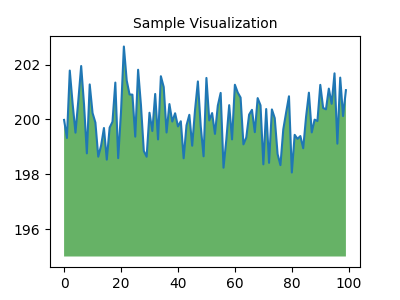

In [70]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

